In [34]:
import pandas as pd
df = pd.read_csv('files/results/final_dataframe.csv')

In [35]:
df

,year,month,brl_usd_price,date,oil_price,conflict_intensity
0,1995,1,0.846091,1995-01-01,16.551905,4
1,1995,2,0.841150,1995-02-01,17.114500,4
2,1995,3,0.890522,1995-03-01,17.006522,4
3,1995,4,0.907400,1995-04-01,18.648333,4
4,1995,5,0.897500,1995-05-01,18.350909,4
...,...,...,...,...,...,...
175,2009,8,1.845314,2009-08-01,72.508571,0
176,2009,9,1.818652,2009-09-01,67.646190,0
177,2009,10,1.737800,2009-10-01,72.769545,0
178,2009,11,1.726800,2009-11-01,76.662000,0


In [36]:
# selecionando variáveis do modelo
df = df.drop(
    columns=['year', 'month', 'date']
)
df

,brl_usd_price,oil_price,conflict_intensity
0,0.846091,16.551905,4
1,0.841150,17.114500,4
2,0.890522,17.006522,4
3,0.907400,18.648333,4
4,0.897500,18.350909,4
...,...,...,...
175,1.845314,72.508571,0
176,1.818652,67.646190,0
177,1.737800,72.769545,0
178,1.726800,76.662000,0


colocando modelo var

In [37]:
from statsmodels.tsa.api import VAR
model = VAR(df)

In [38]:
from statsmodels.tsa.stattools import adfuller as adf

for column in df.columns:
    result = adf(df[column])

    print("Variável:", column)
    print("ADF:", result[0])
    print("p-valor:", result[1])
    print()

Variável: brl_usd_price
ADF: -1.8120294078138872
p-valor: 0.3745059929000962

Variável: oil_price
ADF: -0.7905044207839945
p-valor: 0.821895421615706

Variável: conflict_intensity
ADF: -2.3426873375991595
p-valor: 0.15856968912186536



In [39]:
df['conflict_intensity'].value_counts()

conflict_intensity
0    95
1    61
4    24
Name: count, dtype: int64

como as variáveis não são estacionárias, vamos aplicar diferenciação

In [40]:
df_diff = df.diff().dropna()
df_diff

,brl_usd_price,oil_price,conflict_intensity
1,-0.004941,0.562595,0.0
2,0.049372,-0.107978,0.0
3,0.016878,1.641812,0.0
4,-0.009900,-0.297424,0.0
5,0.016227,-1.038182,0.0
...,...,...,...
175,-0.087494,8.073117,0.0
176,-0.026662,-4.862381,0.0
177,-0.080852,5.123355,0.0
178,-0.011000,3.892455,0.0


In [41]:
df_diff['conflict_intensity'].value_counts()

conflict_intensity
 0.0    175
-1.0      2
-3.0      1
 1.0      1
Name: count, dtype: int64

Vimos que conflict_intensity perde sua capacidade de representar a informação a longo prazo se diferenciarmos. Mesmo não sendo estacionária, vamos optar por manter ela sem diferenciar e depois testar a estabilidade do modelo.

In [42]:
df_var = df.copy()

df_var['brl_usd_price'] = df_var['brl_usd_price'].diff()
df_var['oil_price'] = df_var['oil_price'].diff()

In [45]:
df_var = df_var.dropna()
df_var

,brl_usd_price,oil_price,conflict_intensity
1,-0.004941,0.562595,4
2,0.049372,-0.107978,4
3,0.016878,1.641812,4
4,-0.009900,-0.297424,4
5,0.016227,-1.038182,4
...,...,...,...
175,-0.087494,8.073117,0
176,-0.026662,-4.862381,0
177,-0.080852,5.123355,0
178,-0.011000,3.892455,0


selecionando melhor modelo com até 50 lags e mudando a melhor ordem de acordo com o que faz mais sentido economicamente que nesse caso seria conflito -> oil -> brl_usd

In [66]:
df_var = df_var[[
    'conflict_intensity', 'oil_price', 'brl_usd_price'
]]

model = VAR(df_var)
results = model.select_order(maxlags=30)
print(f"""
Melhor AIC: {results.aic}
Melhor BIC: {results.bic}
Melhor HQ: {results.hqic}
""")

print(results.selected_orders)


Melhor AIC: 2
Melhor BIC: 1
Melhor HQ: 2

{'aic': np.int64(2), 'bic': np.int64(1), 'hqic': np.int64(2), 'fpe': np.int64(2)}


Nesse caso, vamos testar o VAR(1) pelo BIC e o VAR(2) pelo AIC e HQIC e depois analisar sobre a autocorrelação dos resíduos para determinar qual modelo iremos usar.

In [75]:
results1 = model.fit(1)
results2 = model.fit(2)
print(results1.test_whiteness())
print(results2.test_whiteness())

<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 10 is zero: fail to reject at 5% significance level. Test statistic: 73.322, critical value: 103.010>, p-value: 0.716>
<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 10 is zero: fail to reject at 5% significance level. Test statistic: 62.803, critical value: 92.808>, p-value: 0.772>


O critério BIC foi utilizado para a seleção do número de defasagens, pois privilegia modelos mais parcimoniosos, característica desejável em análises econométricas voltadas à interpretação estrutural das relações entre as variáveis.

In [76]:
results1.sigma_u

,conflict_intensity,oil_price,brl_usd_price
conflict_intensity,0.065629,-0.016990,-0.001749
oil_price,-0.016990,18.772895,-0.061755
brl_usd_price,-0.001749,-0.061755,0.008460


Como temos correlação contemporânea entre equações pela matriz, vamos aplicar cholesky nas funções de impulso-resposta e decomposição da variância dos erros

As funções impulso-resposta foram calculadas para um horizonte de 12 períodos à frente, correspondendo a um ano no caso de dados mensais, permitindo avaliar os efeitos dinâmicos de choques nas variáveis do modelo no curto e médio prazo.

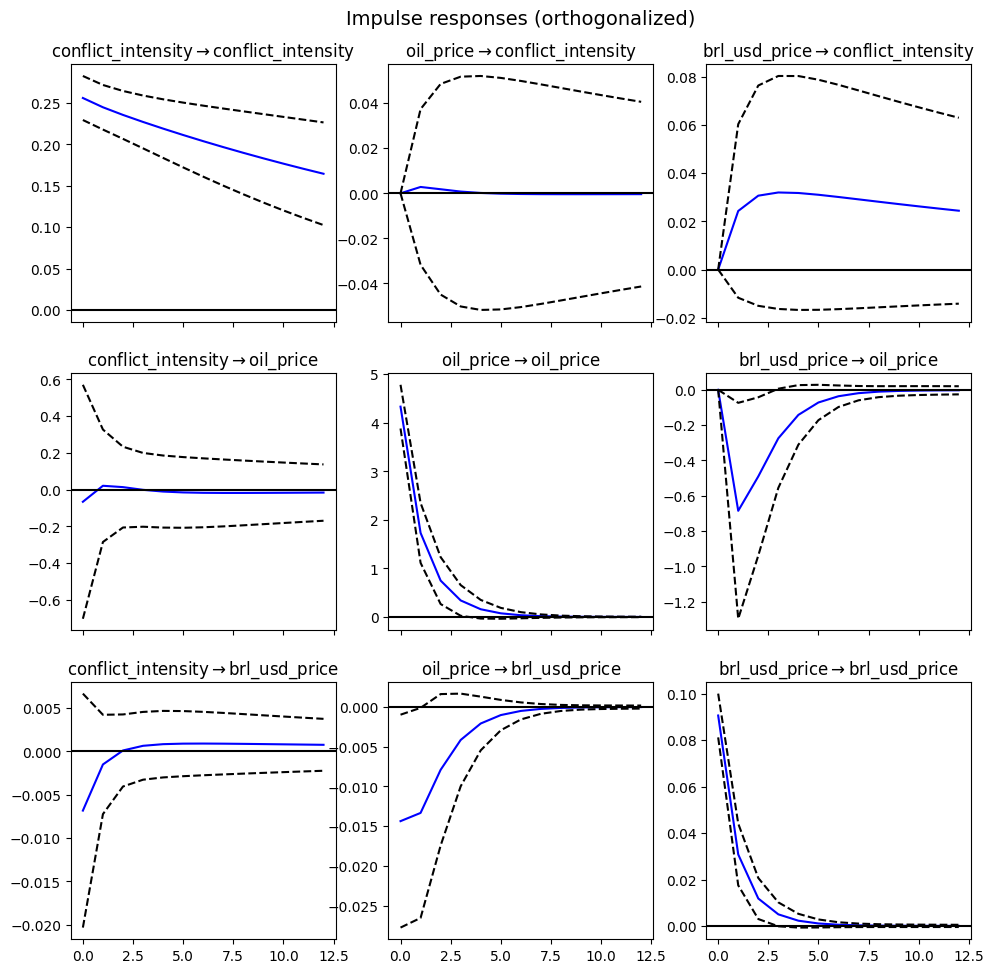

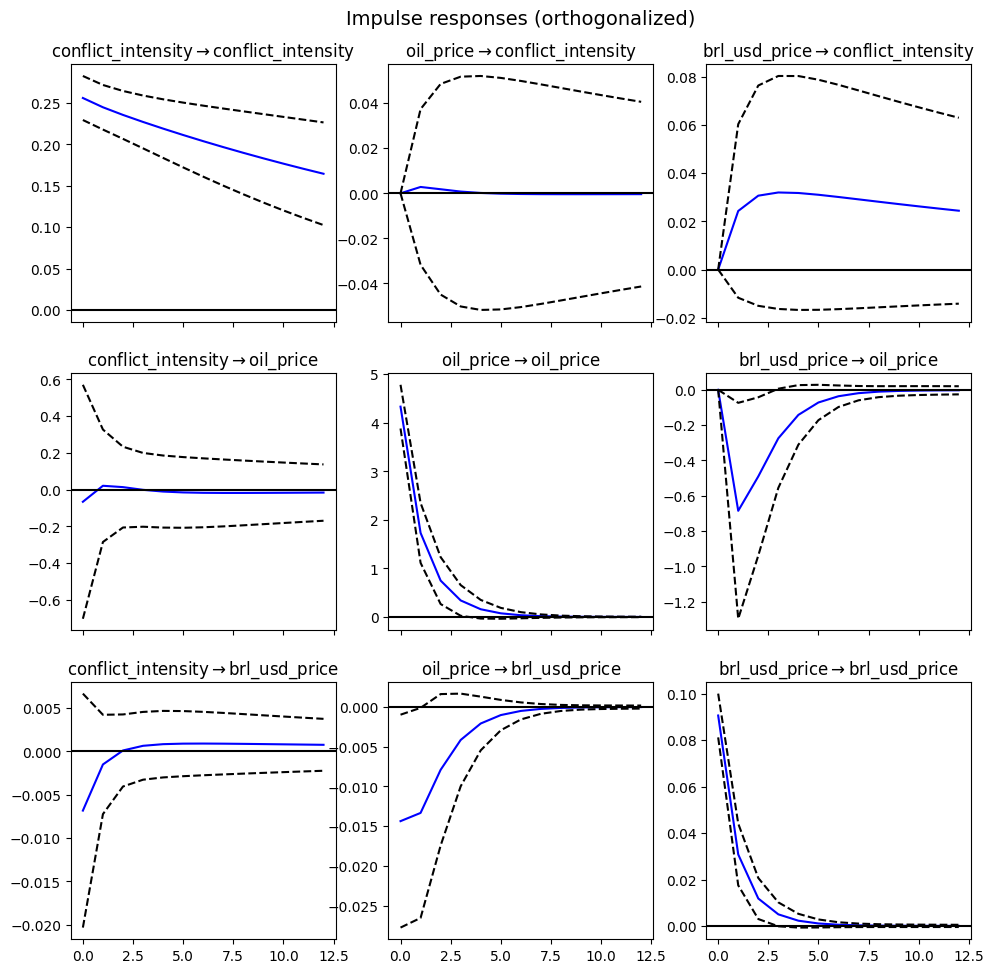

In [80]:
irf = results1.irf(12)
irf.plot(orth=True) #orth=True é usando cholesky

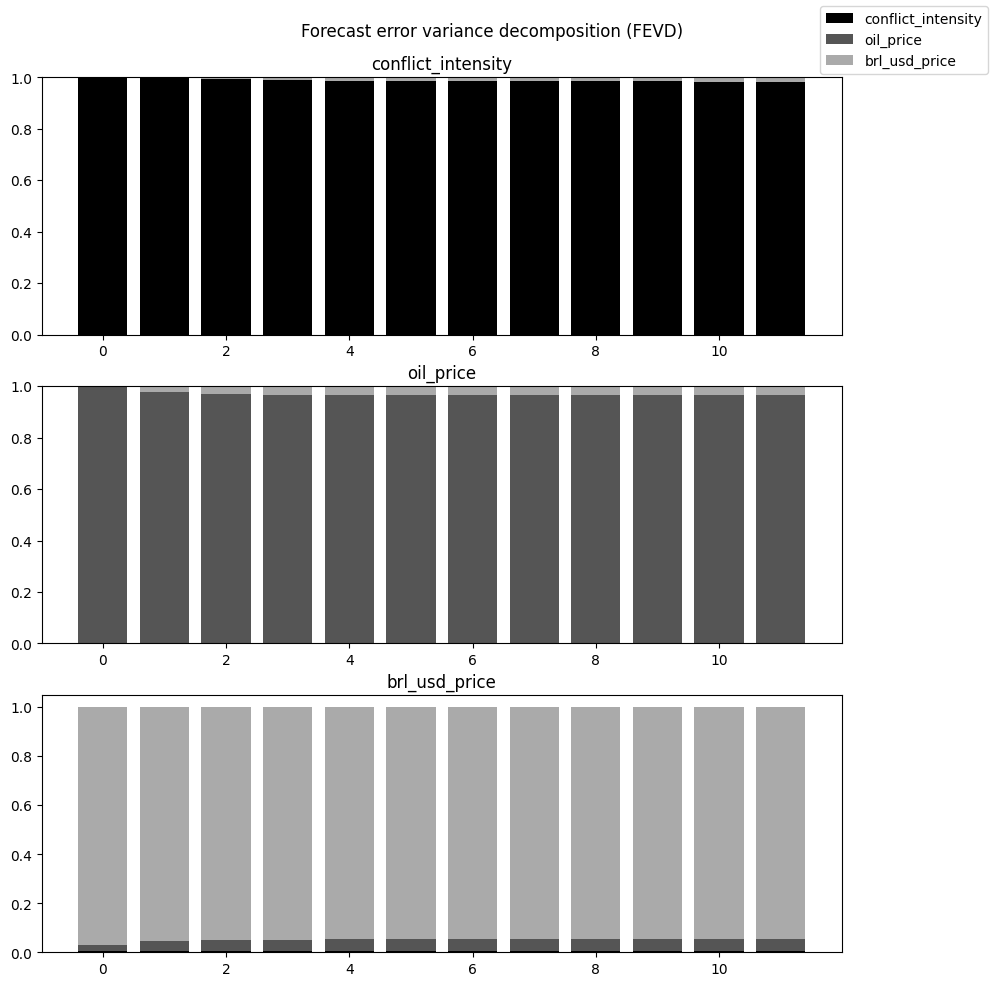

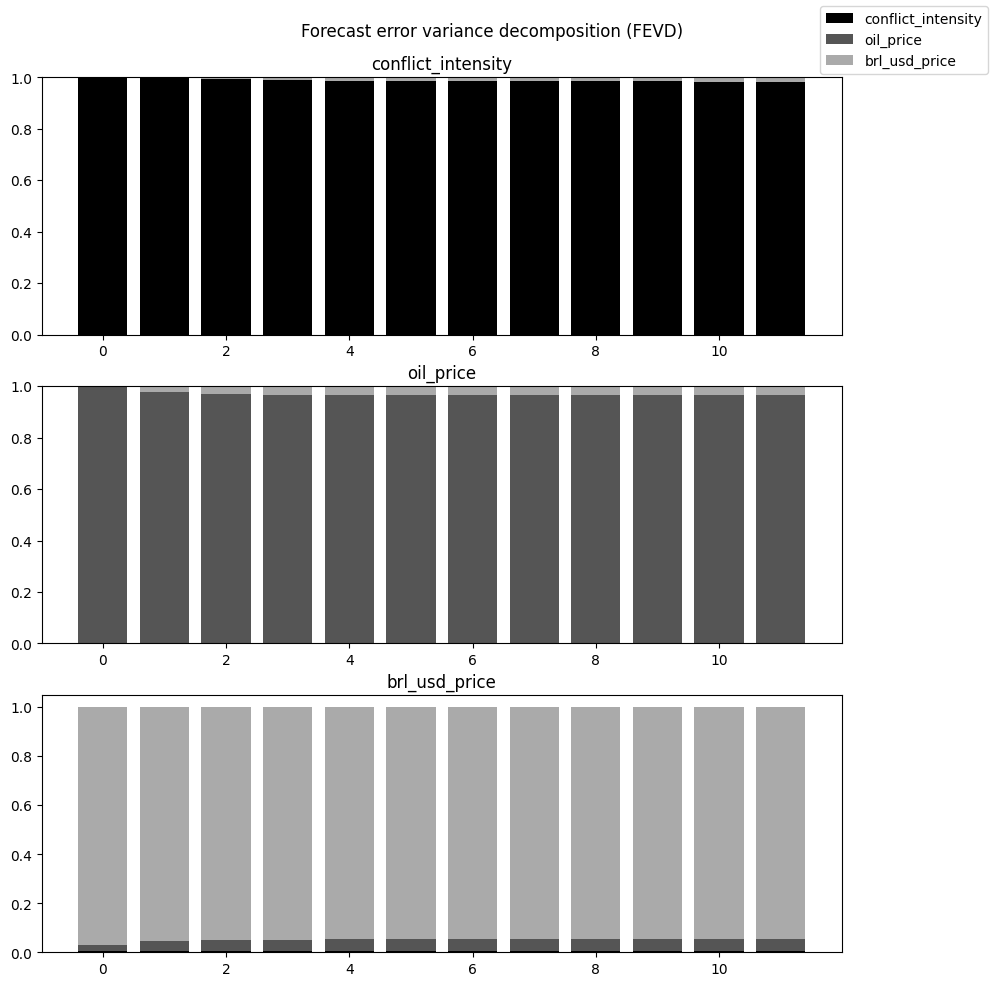

In [81]:
fevd = results1.fevd(12)
fevd.plot()